In [1]:
# ============================================
# NOTEBOOK 5: ML — UNDERVALUED TALENT
# Build a model that scores each African
# player's performance relative to their
# league level — identifying players who
# are outperforming their environment
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

df = pd.read_csv('../data/processed/african_players_clean.csv')

# Work with active players only
active = df[df['minutes'] >= 450].copy()

print("Libraries loaded")
print(f"Total players: {len(df)}")
print(f"Active players (450+ mins): {len(active)}")

Libraries loaded
Total players: 325
Active players (450+ mins): 234


In [2]:
# ============================================
# PERFORMANCE SCORE
# Combine multiple metrics into one score
# that measures how well a player performs
# relative to their position and league
# ============================================

# League difficulty weights
# Higher = harder league
league_weights = {
    'Premier League': 1.0,
    'La Liga': 0.95,
    'Bundesliga': 0.90,
    'Serie A': 0.88,
    'Ligue 1': 0.82
}

active['league_weight'] = active['league'].map(league_weights).fillna(0.85)

# Position weights for goal contributions
# Forwards expected to score more than defenders
position_weights = {
    'Forward': 1.0,
    'Midfielder/Forward': 0.95,
    'Midfielder': 0.85,
    'Defender/Midfielder': 0.75,
    'Defender': 0.65,
    'Goalkeeper': 0.3
}

active['position_weight'] = active['position_clean'].map(
    position_weights
).fillna(0.8)

# Calculate performance score
# Higher league weight = performance worth more
# Lower position weight = outperforming expectations
active['performance_score'] = (
    active['goal_contributions_per90'] *
    active['league_weight'] *
    (2 - active['position_weight'])  # defenders who score get bonus
).round(4)

# Normalise to 0-100 scale
min_score = active['performance_score'].min()
max_score = active['performance_score'].max()
active['performance_score_100'] = (
    (active['performance_score'] - min_score) /
    (max_score - min_score) * 100
).round(1)

print("Performance scores calculated")
print(f"\nScore distribution:")
print(active['performance_score_100'].describe().round(2))
print(f"\nTOP 10 BY PERFORMANCE SCORE:")
top10 = active.nlargest(10, 'performance_score_100')[
    ['player', 'nationality', 'club', 'league',
     'goals', 'assists', 'performance_score_100']
]
print(top10.to_string())

Performance scores calculated

Score distribution:
count    234.00
mean      15.69
std       15.03
min        0.00
25%        3.65
50%       11.80
75%       24.50
max      100.00
Name: performance_score_100, dtype: float64

TOP 10 BY PERFORMANCE SCORE:
              player  nationality            club          league  goals  assists  performance_score_100
31     Mohamed Salah        Egypt       Liverpool  Premier League     29       18                  100.0
180      Amine Harit      Morocco       Marseille         Ligue 1      2        4                   68.0
179     Amine Gouiri      Algeria       Marseille         Ligue 1     10        3                   63.4
3       Bryan Mbeumo     Cameroon       Brentford  Premier League     20        7                   51.8
270  Ademola Lookman      Nigeria        Atalanta         Serie A     15        5                   51.3
225     Sofiane Diop      Morocco            Nice         Ligue 1      6        4                   50.5
5        Yoa

In [3]:
# ============================================
# HIDDEN GEMS — PLAYERS OUTPERFORMING
# THEIR LEAGUE LEVEL
# Players in Ligue 1 or lower leagues with
# Premier League level performance scores
# ============================================

# Calculate expected score based on league average
league_avg_score = active.groupby('league')[
    'performance_score_100'
].mean()

active['league_avg_score'] = active['league'].map(league_avg_score)
active['outperformance'] = (
    active['performance_score_100'] - active['league_avg_score']
).round(1)

# Hidden gems = high outperformance + NOT in Premier League
hidden_gems = active[
    active['league'] != 'Premier League'
].nlargest(10, 'outperformance')[
    ['player', 'nationality', 'club', 'league',
     'age', 'position_clean', 'goals', 'assists',
     'performance_score_100', 'outperformance']
]

print("TOP 10 HIDDEN GEMS")
print("Players massively outperforming their league level")
print("=" * 75)
for _, row in hidden_gems.iterrows():
    print(f"\n{row['player']} ({row['nationality']}) — Age {row['age']:.0f}")
    print(f"  Club: {row['club']} | League: {row['league']}")
    print(f"  Goals: {row['goals']:.0f} | Assists: {row['assists']:.0f}")
    print(f"  Performance Score: {row['performance_score_100']:.1f}/100")
    print(f"  Outperformance vs league average: +{row['outperformance']:.1f}")

TOP 10 HIDDEN GEMS
Players massively outperforming their league level

Amine Harit (Morocco) — Age 27
  Club: Marseille | League: Ligue 1
  Goals: 2 | Assists: 4
  Performance Score: 68.0/100
  Outperformance vs league average: +53.6

Amine Gouiri (Algeria) — Age 24
  Club: Marseille | League: Ligue 1
  Goals: 10 | Assists: 3
  Performance Score: 63.4/100
  Outperformance vs league average: +49.0

Ademola Lookman (Nigeria) — Age 26
  Club: Atalanta | League: Serie A
  Goals: 15 | Assists: 5
  Performance Score: 51.3/100
  Outperformance vs league average: +37.7

Sofiane Diop (Morocco) — Age 24
  Club: Nice | League: Ligue 1
  Goals: 6 | Assists: 4
  Performance Score: 50.5/100
  Outperformance vs league average: +36.1

Abdallah Sima (Senegal) — Age 23
  Club: Brest | League: Ligue 1
  Goals: 7 | Assists: 2
  Performance Score: 44.6/100
  Outperformance vs league average: +30.2

Nicolas Pépé (Ivory Coast) — Age 29
  Club: Villarreal | League: La Liga
  Goals: 3 | Assists: 6
  Performanc

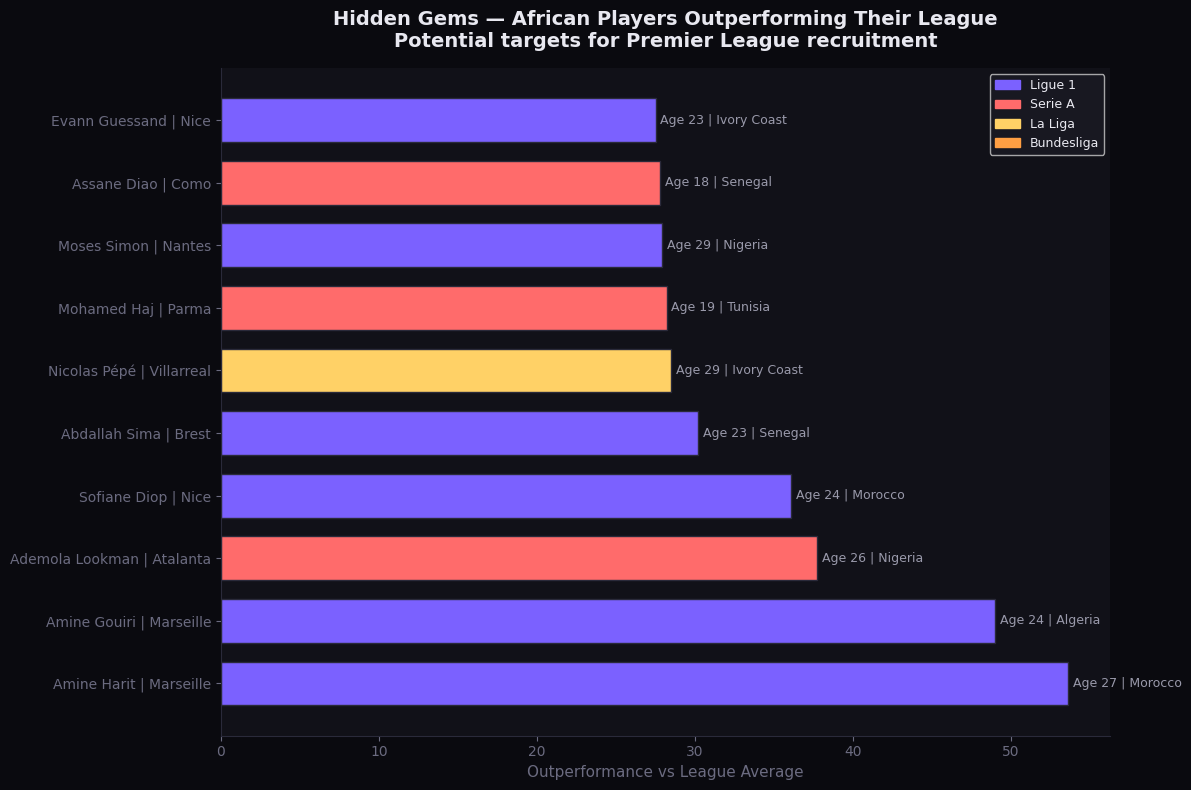

Hidden gems chart saved


In [4]:
# ============================================
# HIDDEN GEMS CHART
# ============================================

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

league_colors = {
    'Ligue 1': '#7b61ff',
    'Serie A': '#ff6b6b',
    'La Liga': '#ffd166',
    'Bundesliga': '#ff9f43'
}

colors = [league_colors.get(l, '#4a4a6a')
          for l in hidden_gems['league']]

bars = ax.barh(
    range(len(hidden_gems)),
    hidden_gems['outperformance'],
    color=colors, edgecolor='#2a2a3a',
    height=0.7
)

ax.set_yticks(range(len(hidden_gems)))
ax.set_yticklabels([
    f"{row['player']} | {row['club']}"
    for _, row in hidden_gems.iterrows()
], color='#e8e8f0', fontsize=10)

for bar, (_, row) in zip(bars, hidden_gems.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"Age {row['age']:.0f} | {row['nationality']}",
        va='center', color='#9999aa', fontsize=9
    )

ax.set_title(
    'Hidden Gems — African Players Outperforming Their League\n'
    'Potential targets for Premier League recruitment',
    color='#e8e8f0', fontsize=14,
    fontweight='bold', pad=15
)
ax.set_xlabel('Outperformance vs League Average',
              color='#6b6b80', fontsize=11)
ax.tick_params(colors='#6b6b80')
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for l, c in league_colors.items()
]
ax.legend(handles=legend_patches,
          facecolor='#1a1a24',
          labelcolor='#e8e8f0', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/hidden_gems.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Hidden gems chart saved")